# Merge IESO Electricity Demand with Weather Data

**Purpose:** Combine hourly electricity demand data with weather features for ML modeling.

**Datasets:**
- IESO Ontario Demand (2010-2025): 138,984 hourly records
- Environment Canada Weather (2013-2025): 109,584 hourly records

**Process:**
1. Load both cleaned datasets
2. Filter IESO to match weather date range (June 2013 - Nov 2025)
3. Merge on DateTime column
4. Verify data quality
5. Save final merged dataset

**Output:** Single CSV with electricity demand + weather features, ready for ML modeling.

In [1]:
# Import libraries for data merging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries loaded")

Libraries loaded


In [2]:
# Load cleaned IESO demand data
ieso_path = "../../02_Datasets/processed/ieso_demand_2010_2025_cleaned.csv"
ieso_data = pd.read_csv(ieso_path, parse_dates=['DateTime'])

print("IESO Electricity Demand Data:")
print(f"  Records: {len(ieso_data):,}")
print(f"  Date range: {ieso_data['DateTime'].min()} to {ieso_data['DateTime'].max()}")
print(f"  Columns: {ieso_data.columns.tolist()}")

print("\n" + "="*70)

# Load cleaned weather data
weather_path = "../../02_Datasets/processed/weather_toronto_2013_2025_cleaned.csv"
weather_data = pd.read_csv(weather_path, parse_dates=['DateTime'])

print("Weather Data:")
print(f"  Records: {len(weather_data):,}")
print(f"  Date range: {weather_data['DateTime'].min()} to {weather_data['DateTime'].max()}")
print(f"  Columns: {weather_data.columns.tolist()}")

IESO Electricity Demand Data:
  Records: 138,984
  Date range: 2010-01-01 00:00:00 to 2025-11-09 00:00:00
  Columns: ['DateTime', 'Date', 'Hour', 'Year', 'Month', 'DayOfWeek', 'DayOfYear', 'IsWeekend', 'Market Demand', 'Ontario Demand']

Weather Data:
  Records: 109,584
  Date range: 2013-06-01 00:00:00 to 2025-11-30 23:00:00
  Columns: ['DateTime', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)']


In [3]:
# Filter IESO data to match weather date range
weather_start = weather_data['DateTime'].min()
weather_end = weather_data['DateTime'].max()

print(f"Weather data range: {weather_start} to {weather_end}")
print(f"Filtering IESO data to match...")

ieso_filtered = ieso_data[(ieso_data['DateTime'] >= weather_start) & 
                           (ieso_data['DateTime'] <= weather_end)].copy()

print(f"\nIESO data after filtering:")
print(f"  Original records: {len(ieso_data):,}")
print(f"  Filtered records: {len(ieso_filtered):,}")
print(f"  Dropped: {len(ieso_data) - len(ieso_filtered):,} records (2010-2012 + recent hours)")
print(f"  Date range: {ieso_filtered['DateTime'].min()} to {ieso_filtered['DateTime'].max()}")

Weather data range: 2013-06-01 00:00:00 to 2025-11-30 23:00:00
Filtering IESO data to match...

IESO data after filtering:
  Original records: 138,984
  Filtered records: 109,056
  Dropped: 29,928 records (2010-2012 + recent hours)
  Date range: 2013-06-01 00:00:00 to 2025-11-09 00:00:00


In [4]:
# Merge IESO and weather data on DateTime
merged_data = pd.merge(ieso_filtered, weather_data, on='DateTime', how='inner')

print("Merge Results:")
print(f"  IESO records: {len(ieso_filtered):,}")
print(f"  Weather records: {len(weather_data):,}")
print(f"  Merged records: {len(merged_data):,}")

print("\n" + "="*70)
print("Merged dataset columns:")
print(merged_data.columns.tolist())

print("\n" + "="*70)
print("Date range of merged data:")
print(f"  Start: {merged_data['DateTime'].min()}")
print(f"  End: {merged_data['DateTime'].max()}")

print("\n" + "="*70)
print("First 5 rows:")
merged_data.head()

Merge Results:
  IESO records: 109,056
  Weather records: 109,584
  Merged records: 109,056

Merged dataset columns:
['DateTime', 'Date', 'Hour', 'Year', 'Month', 'DayOfWeek', 'DayOfYear', 'IsWeekend', 'Market Demand', 'Ontario Demand', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)']

Date range of merged data:
  Start: 2013-06-01 00:00:00
  End: 2025-11-09 00:00:00

First 5 rows:


,DateTime,Date,Hour,Year,Month,DayOfWeek,DayOfYear,IsWeekend,Market Demand,Ontario Demand,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Dir (10s deg),Wind Spd (km/h),Visibility (km),Stn Press (kPa)
0,2013-06-01 00:00:00,2013-06-01,1,2013,6,5,152,1,15908,13731,17.8,16.0,89.0,0.0,21.0,24.1,98.66
1,2013-06-01 01:00:00,2013-06-01,2,2013,6,5,152,1,15126,13143,17.8,16.0,89.0,0.0,21.0,24.1,98.66
2,2013-06-01 02:00:00,2013-06-01,3,2013,6,5,152,1,14652,12778,17.8,16.0,89.0,0.0,21.0,24.1,98.66
3,2013-06-01 03:00:00,2013-06-01,4,2013,6,5,152,1,14309,12509,17.8,16.0,89.0,0.0,21.0,24.1,98.66
4,2013-06-01 04:00:00,2013-06-01,5,2013,6,5,152,1,14473,12574,17.8,16.0,89.0,0.0,21.0,24.1,98.66


In [5]:
# Check for any issues in merged data
print("Data Quality Check:")
print("="*70)

# Missing values
print("Missing values:")
print(merged_data.isnull().sum())

print("\n" + "="*70)
print("Data types:")
print(merged_data.dtypes)

print("\n" + "="*70)
print("Ontario Demand statistics:")
print(merged_data['Ontario Demand'].describe())

print("\n" + "="*70)
print("Temperature statistics:")
print(merged_data['Temp (°C)'].describe())

print("\n" + "="*70)
print(f"Total records: {len(merged_data):,}")
print(f"Memory usage: {merged_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Data Quality Check:
Missing values:
DateTime               0
Date                   0
Hour                   0
Year                   0
Month                  0
DayOfWeek              0
DayOfYear              0
IsWeekend              0
Market Demand          0
Ontario Demand         0
Temp (°C)              0
Dew Point Temp (°C)    0
Rel Hum (%)            0
Wind Dir (10s deg)     0
Wind Spd (km/h)        0
Visibility (km)        0
Stn Press (kPa)        0
dtype: int64

Data types:
DateTime               datetime64[ns]
Date                           object
Hour                            int64
Year                            int64
Month                           int64
DayOfWeek                       int64
DayOfYear                       int64
IsWeekend                       int64
Market Demand                   int64
Ontario Demand                  int64
Temp (°C)                     float64
Dew Point Temp (°C)           float64
Rel Hum (%)                   float64
Wind Dir (10s deg) 

In [7]:
import os  # Add this import

# Save the final merged dataset
output_path = "../../02_Datasets/processed/final_merged_ieso_weather.csv"
merged_data.to_csv(output_path, index=False)

print("✓ Final merged dataset saved!")
print(f"\nFile: {output_path}")
print(f"Size: {os.path.getsize(output_path) / 1024**2:.1f} MB")
print(f"Records: {len(merged_data):,}")
print(f"Features: {len(merged_data.columns)}")
print(f"Date range: {merged_data['DateTime'].min()} to {merged_data['DateTime'].max()}")

print("\n" + "="*70)
print("Dataset ready for ML modeling! 🚀")
print("\nFeatures available:")
print(f"  Target: Ontario Demand")
print(f"  Time features: {['Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'IsWeekend']}")
print(f"  Weather features: {['Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)']}")

✓ Final merged dataset saved!

File: ../../02_Datasets/processed/final_merged_ieso_weather.csv
Size: 10.1 MB
Records: 109,056
Features: 17
Date range: 2013-06-01 00:00:00 to 2025-11-09 00:00:00

Dataset ready for ML modeling! 🚀

Features available:
  Target: Ontario Demand
  Time features: ['Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'IsWeekend']
  Weather features: ['Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)']


✓ Saved visualization to: ../../04_Presentation/weather_demand_analysis.png


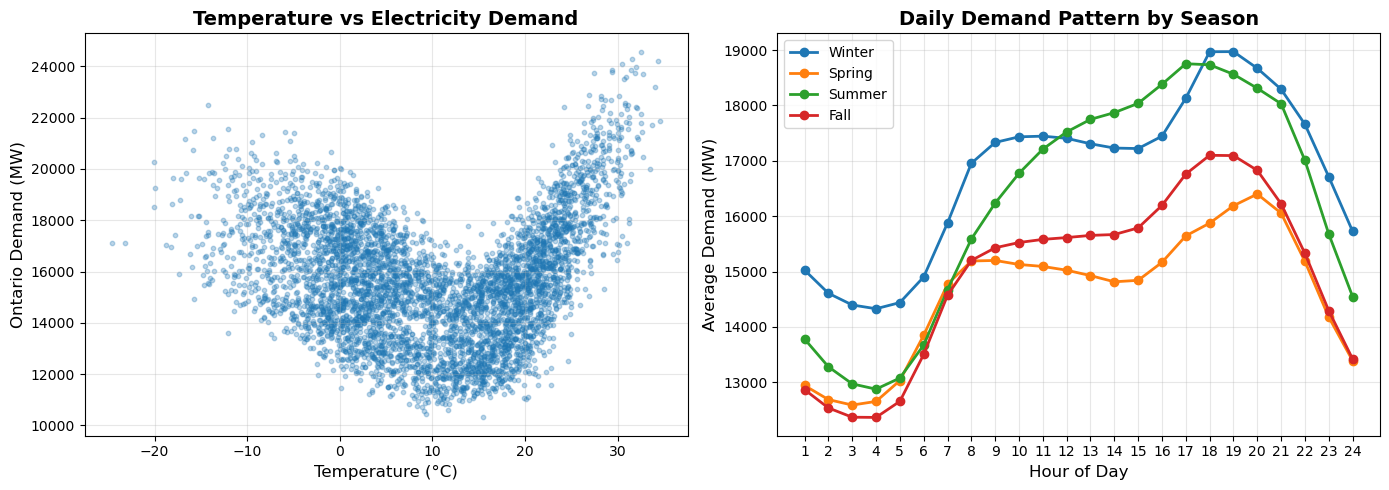

In [8]:
# Create visualization showing temp vs demand relationship
plt.figure(figsize=(14, 5))

# Plot 1: Temperature vs Demand scatter
plt.subplot(1, 2, 1)
sample = merged_data.sample(5000)  # Sample 5000 points for faster plotting
plt.scatter(sample['Temp (°C)'], sample['Ontario Demand'], alpha=0.3, s=10)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Ontario Demand (MW)', fontsize=12)
plt.title('Temperature vs Electricity Demand', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2: Average demand by hour and season
plt.subplot(1, 2, 2)
merged_data['Season'] = merged_data['Month'].map({12:1, 1:1, 2:1,  # Winter
                                                    3:2, 4:2, 5:2,   # Spring
                                                    6:3, 7:3, 8:3,   # Summer
                                                    9:4, 10:4, 11:4}) # Fall
season_hourly = merged_data.groupby(['Hour', 'Season'])['Ontario Demand'].mean().reset_index()
for season, label in [(1, 'Winter'), (2, 'Spring'), (3, 'Summer'), (4, 'Fall')]:
    data = season_hourly[season_hourly['Season'] == season]
    plt.plot(data['Hour'], data['Ontario Demand'], marker='o', label=label, linewidth=2)

plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Demand (MW)', fontsize=12)
plt.title('Daily Demand Pattern by Season', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 25))

plt.tight_layout()

# Save figure
fig_path = "../../04_Presentation/weather_demand_analysis.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved visualization to: {fig_path}")

plt.show()